# ETF Decay Capture Backtest

**Universe and borrow still come from the existing IBKR large-AUM inputs, but sizing now mirrors the selected Bucket 1 GTP path from Diamond v16 / `generate_trade_plan.py`.**

- **Borrow rates:** IBKR *average* borrow (`borrow_avg_annual` from `etf-dashboard/data/dashboard_data.json`).
- **AUM filter:** only trade ETFs with AUM `> $20M` (`etf-dashboard/data/etf_metrics_daily.csv`, yfinance fallback).
- **Sizing:** Bucket 1/core-only GTP mirror sizing using net-edge score, selected borrow aversion, selected score concavity, covariance balance, and production gross sizing caps.
- **Universe:** Bucket 1 candidates only after the existing AUM and price-overlap gates.

Outputs: CAGR, annualised vol, max drawdown, a stacked-area chart of each pair’s % of total gross over time, plus a bar chart of gross concentration by underlying.

## Setup

In [17]:
import warnings; warnings.filterwarnings("ignore")
import copy, importlib, json, io, time, os, ftplib, sys
import numpy as np, pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import yaml

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration

In [ ]:
CFG = {
    "capital_usd":          25_000_000,
    "start_date":           "2024-01-01",
    "slippage_bps":         10,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,
    "fallback_borrow_rate": 0.02,
    "margin_debit_spreads": [
        (100_000,      0.015),
        (1_000_000,    0.010),
        (50_000_000,   0.0075),
        (float("inf"), 0.005),
    ],
    "credit_threshold":     10_000,
    "credit_spread":        -0.005,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,
    # --- v8 sizing knobs (v15-style caps) ---
    "aum_min_usd":            20_000_000,   # universe filter: only ETFs with AUM > $20m
    "aum_use_pct":            0.02,        # short position <= 2% of reported AUM
    "short_avail_use_pct":    0.25,        # short position <= 25% of reported shares_available
    "max_pair_weight_cap":    0.075,       # per-pair weight cap (% of gross)
    "max_underlying_weight_cap": 0.15,     # per-underlying weight cap
    "missing_shares_cap":     0.02,        # fallback cap when shares_available missing
    "decay_weight_power":     1.25,        # exponent on net_decay signal
    "min_net_decay_annual":   0.05,        # sizing: require net_decay_annual > 5% (else zero weight)
    "borrow_penalty_mult":    3.0,         # sizing: score /= (1 + mult * borrow_annual); higher = penalize borrow more
    "use_pair_pnl_filter":    True,        # if ALL_PAIR_PNL exists, exclude ETFs with negative cumulative pair P&L
    "cap_ramp_rebals":        3,           # rebalances to ramp cap-constrained names in
}

LEVERAGE_RUNS = [3.5]

V7_TARGET_LEV_START = 3.25
V7_TARGET_LEV_END   = 3.75

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  target gross multiple: {V7_TARGET_LEV_START}x -> {V7_TARGET_LEV_END}x")
print(f"Universe filter: AUM > ${CFG['aum_min_usd']:,}  |  Bucket 1 candidates only")
print("Sizing: GTP mirror Bucket 1/core_leveraged selected params from Diamond v16")


Capital: $25,000,000  |  Start: 2023-01-01
Leverage: [3.5]  |  target gross multiple: 3.25x -> 3.75x
Universe filter: AUM > $20,000,000  |  Bucket 1 candidates only
Sizing: GTP mirror Bucket 1/core_leveraged selected params from Diamond v16


## ETF Dashboard inputs — AUM, IBKR avg borrow, shares available

Pulls the latest snapshot from the sibling `etf-dashboard` repo at `../etf-dashboard/data/`. This gives us:
- `borrow_avg_annual` — average IBKR borrow fee (used everywhere as *the* borrow rate).
- `shares_available` — most recent IBKR lendable share count.
- `net_decay_annual` (from `net_decay`) — expected P&L signal used to size positions.
- `aum` per ticker — used for the $20M universe filter and the AUM cap.

In [19]:
# ---- Load ETF-dashboard inputs (AUM, IBKR avg borrow, shares, net decay) ----
dashboard_candidates = [
    Path("../etf-dashboard/data"),
    Path("../../etf-dashboard/data"),
    Path.cwd().parent / "etf-dashboard/data",
    Path(r"C:/Users/werdn/Documents/Investing/etf-dashboard/data"),
]
DASHBOARD_DIR = next((p for p in dashboard_candidates if p.exists()), None)
if DASHBOARD_DIR is None:
    raise FileNotFoundError(
        "Could not locate etf-dashboard/data. Checked: "
        + ", ".join(str(p) for p in dashboard_candidates)
    )
print(f"[dashboard] Using {DASHBOARD_DIR}")

with open(DASHBOARD_DIR / "dashboard_data.json", "r", encoding="utf-8") as f:
    _dash = json.load(f)
_records = _dash.get("records", []) or []
print(f"[dashboard] records loaded: {len(_records)}")

_dash_rows = []
for r in _records:
    beta_val = pd.to_numeric(r.get("beta"), errors="coerce")
    if pd.notna(beta_val) and float(beta_val) > 1.5:
        sym = str(r.get("symbol", "")).upper().strip().replace(".", "-")
        if not sym:
            continue
        _dash_rows.append({
            "ETF": sym,
            "Underlying": str(r.get("underlying", "")).upper().strip().replace(".", "-"),
            "Beta": r.get("beta"),
            "bucket": r.get("bucket"),
            "borrow_avg_annual": r.get("borrow_avg_annual"),
            "borrow_current": r.get("borrow_current"),
            "borrow_net_annual": r.get("borrow_net_annual"),
            "shares_available": r.get("shares_available"),
            "gross_decay_annual": r.get("gross_decay_annual"),
            "net_decay_annual": r.get("net_decay"),
        })
dash_df = pd.DataFrame(_dash_rows)
for c in ["Beta", "borrow_avg_annual", "borrow_current", "borrow_net_annual",
          "shares_available", "gross_decay_annual", "net_decay_annual"]:
    dash_df[c] = pd.to_numeric(dash_df[c], errors="coerce")
dash_df = dash_df.drop_duplicates(subset=["ETF"], keep="last").reset_index(drop=True)
print(
    f"[dashboard] unique tickers: {dash_df['ETF'].nunique()} | "
    f"with borrow_avg: {dash_df['borrow_avg_annual'].notna().sum()} | "
    f"with shares_avail: {dash_df['shares_available'].notna().sum()} | "
    f"with net_decay: {dash_df['net_decay_annual'].notna().sum()}"
)

# ---- AUM from etf_metrics_daily.csv (latest non-na per ticker) ----
aum_csv = DASHBOARD_DIR / "etf_metrics_daily.csv"
aum_df = pd.read_csv(aum_csv)
aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")
aum_df["ticker"] = aum_df["ticker"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
aum_df["aum"] = pd.to_numeric(aum_df["aum"], errors="coerce")
aum_df["shares_outstanding"] = pd.to_numeric(aum_df.get("shares_outstanding"), errors="coerce")
_aum_sorted = aum_df.dropna(subset=["aum"]).sort_values("date")
aum_latest = _aum_sorted.groupby("ticker", as_index=False).tail(1)[[
    "ticker", "aum", "shares_outstanding"
]].rename(columns={"ticker": "ETF", "aum": "aum_usd"})
print(
    f"[dashboard] AUM coverage: {aum_latest['ETF'].nunique()} tickers | "
    f"median AUM: ${aum_latest['aum_usd'].median():,.0f} | "
    f">${CFG['aum_min_usd']:,}: {(aum_latest['aum_usd'] > CFG['aum_min_usd']).sum()}"
)

DASH_DF = dash_df.merge(aum_latest, on="ETF", how="left")

# Convenience maps for downstream cells.
BORROW_AVG_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["borrow_avg_annual"], errors="coerce"))
)
SHARES_AVAIL_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["shares_available"], errors="coerce"))
)
NET_DECAY_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["net_decay_annual"], errors="coerce"))
)
AUM_MAP = dict(zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["aum_usd"], errors="coerce")))
SHARES_OUT_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["shares_outstanding"], errors="coerce"))
)


[dashboard] Using ..\..\etf-dashboard\data
[dashboard] records loaded: 430
[dashboard] unique tickers: 300 | with borrow_avg: 296 | with shares_avail: 300 | with net_decay: 280
[dashboard] AUM coverage: 466 tickers | median AUM: $22,485,000 | >$20,000,000: 237


## Universe — large-AUM candidates, later restricted to Bucket 1 sizing

Same hardcoded core pair list as v7/v8 before; we additionally add any pair that appears in `data/etf_screened_today.csv`. The **AUM > $20M** filter remains the first gate. The sizing cell below then applies the GTP mirror Bucket 1/core eligibility rules and restricts the backtest universe to positive-gross Bucket 1 rows only.

In [20]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map").
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]
_pre_screen_candidates = list(CANDIDATES)
_base_keys = {(e, u) for e, u, _ in CANDIDATES}


# Augment from latest screener CSV (all buckets; no beta filter here — AUM is the gate).
_screen_candidates = [
    Path("../data/etf_screened_today.csv"),
    Path("data/etf_screened_today.csv"),
    DASHBOARD_DIR / "etf_screened_today.csv",
]
_screen_path = next((p for p in _screen_candidates if p.exists()), None)
added_from_screener = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    if {"ETF", "Underlying", "Beta"}.issubset(_sc.columns):
        for r in _sc.itertuples(index=False):
            e = str(r.ETF).upper().strip().replace(".", "-")
            u = str(r.Underlying).upper().strip().replace(".", "-")
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in _base_keys:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            _base_keys.add(key)
            added_from_screener += 1
print(f"Core + screener candidates: {len(CANDIDATES)} ({added_from_screener} from screener)")

# ---- AUM > $20M filter ----
aum_min = float(CFG["aum_min_usd"])
filtered, dropped_aum, dropped_missing = [], 0, 0
for e, u, b in CANDIDATES:
    aum = AUM_MAP.get(e)
    if aum is None or not np.isfinite(aum):
        dropped_missing += 1
        continue
    if aum <= aum_min:
        dropped_aum += 1
        continue
    filtered.append((e, u, b))
CANDIDATES = filtered
print(
    f"After AUM>${aum_min:,.0f} filter: {len(CANDIDATES)} pairs "
    f"(dropped: {dropped_aum} below threshold, {dropped_missing} missing AUM)"
)


Core + screener candidates: 426 (304 from screener)
After AUM>$20,000,000 filter: 144 pairs (dropped: 155 below threshold, 127 missing AUM)


## Data — IBKR avg borrow + total-return prices + Fed Funds

In [21]:
# ---- Borrow rates from etf-dashboard (IBKR avg) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]

BORROW_MAP = {}
src_avg = src_net = src_cur = src_flat = 0
for e in all_etf_syms:
    v_avg = BORROW_AVG_MAP.get(e)
    if v_avg is not None and np.isfinite(v_avg) and v_avg > 0:
        BORROW_MAP[e] = float(v_avg)
        src_avg += 1
        continue
    row = DASH_DF.loc[DASH_DF["ETF"] == e]
    v_net = float(row["borrow_net_annual"].iloc[0]) if not row.empty else np.nan
    v_cur = float(row["borrow_current"].iloc[0]) if not row.empty else np.nan
    if np.isfinite(v_net) and v_net > 0:
        BORROW_MAP[e] = v_net; src_net += 1
    elif np.isfinite(v_cur) and v_cur > 0:
        BORROW_MAP[e] = v_cur; src_cur += 1
    else:
        BORROW_MAP[e] = float(CFG["fallback_borrow_rate"]); src_flat += 1

print(
    f"[BORROW] IBKR borrow_avg_annual: {src_avg}/{len(all_etf_syms)} | "
    f"net_annual: {src_net} | current: {src_cur} | flat fallback: {src_flat}"
)
print(
    f"[BORROW] mean rate (applied): "
    f"{np.mean([v for v in BORROW_MAP.values()]):.2%}"
)


[BORROW] IBKR borrow_avg_annual: 144/144 | net_annual: 0 | current: 0 | flat fallback: 0
[BORROW] mean rate (applied): 14.50%


In [22]:
# ---- Total-return prices (yfinance adjusted close) ----
import yfinance as yf

MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {"2026-01-26": 10.0},
    "EOSU": {"2026-04-08": 25.0},
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()
        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw = tkr in manual_splits
        if (not force_raw) and ("Adj Close" in df.columns) and df["Adj Close"].notna().sum() > 20:
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()
        close = df["Close"].astype(float)
        divs = df["Dividends"].fillna(0).astype(float) if "Dividends" in df.columns else pd.Series(0.0, index=close.index)
        splits = df["Stock Splits"].replace(0, 1).fillna(1).astype(float) if "Stock Splits" in df.columns else pd.Series(1.0, index=close.index)
        if tkr in manual_splits:
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]
                if apply_ts is None:
                    continue
                f = float(factor)
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f
                splits.loc[apply_ts] = 1.0
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except Exception:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 40 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")

# ---- Fed Funds ----
try:
    ff_df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF")
    ff_df.columns = [str(c).strip() for c in ff_df.columns]
    date_col = "DATE" if "DATE" in ff_df.columns else "observation_date"
    ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
    ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
    ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
    print(f"Fed Funds: {len(FED_FUNDS_DAILY)} daily obs")
except Exception as e:
    print(f"FRED failed ({e}); using constant 4% fallback")
    FED_FUNDS_DAILY = pd.Series([0.04], index=[pd.Timestamp("2020-01-01")])


  40/243 [2s]
  80/243 [5s]
  120/243 [7s]
  160/243 [10s]
  200/243 [12s]
  240/243 [15s]
Got 241/243 [14.7s]
Fed Funds: 26244 daily obs


In [23]:
# ---- Inception dates + full UNIVERSE (pairs with overlapping price data) ----
start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf); s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        INCEPTION[(etf, und)] = max(s_e.index[0], s_u.index[0])

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
RAMP_WEEKS = 4
n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(
    f"Full UNIVERSE: {len(UNIVERSE)} pairs | tradeable at start ({CFG['start_date']}): {n_at_start} | "
    f"RAMP_WEEKS={RAMP_WEEKS}"
)


Full UNIVERSE: 142 pairs | tradeable at start (2023-01-01): 26 | RAMP_WEEKS=4


## Cost functions

In [24]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    return max(cfg["ibkr_comm_min"], min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"])) + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / TRADING_DAYS
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    return short_notional * max(0.0, benchmark_rate + credit_spread) / TRADING_DAYS

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / ny) - 1 if ny > 0 else np.nan
    vol = r.std() * (TRADING_DAYS ** 0.5)
    sr = cagr / vol if vol > 0 else np.nan
    dd = (nav - nav.cummax()) / nav.cummax()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Max DD": dd.min(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}
print("Cost functions OK")


Cost functions OK


## Sizing — GTP mirror Bucket 1/core only

This cell builds a GTP-compatible screened frame from the existing IBKR large-AUM universe, then calls `mirror_generate_trade_plan_sizing` with the same selected Bucket 1 parameters used in `Diamond_Creek_Backtest_v16.ipynb`.

The backtest keeps its existing AUM gate, borrow source, price data, leverage ramp, and execution engine. The only sizing change is that positive-gross rows must pass Bucket 1/core eligibility and receive weights from the GTP mirror path.

In [25]:
# ---- Build sizing weights: GTP mirror Bucket 1/core only ----
def _find_repo_root_ibkr() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "config" / "strategy_config.yml").exists() and (p / "scripts" / "gtp_sizing_mirror.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root with config/strategy_config.yml and scripts/gtp_sizing_mirror.py")


REPO_ROOT_IBKR = _find_repo_root_ibkr()
if str(REPO_ROOT_IBKR) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT_IBKR))

with open(REPO_ROOT_IBKR / "config" / "strategy_config.yml", "r", encoding="utf-8") as f:
    STRATEGY_CFG_IBKR = yaml.safe_load(f) or {}

import generate_trade_plan as _gtp_live
import scripts.gtp_sizing_mirror as _gsm_live

importlib.reload(_gtp_live)
importlib.reload(_gsm_live)

from scripts.gtp_sizing_mirror import mirror_generate_trade_plan_sizing

strategy_cfg_ibkr = STRATEGY_CFG_IBKR.setdefault("strategy", {})
sleeves_cfg_ibkr = STRATEGY_CFG_IBKR.setdefault("portfolio", {}).setdefault("sleeves", {})
_GROSS_CAPS_PS_IBKR = (strategy_cfg_ibkr.get("gross_sizing_caps") or {}).get("per_sleeve") or {}
_B1_CAPS_IBKR = _GROSS_CAPS_PS_IBKR.get("core_leveraged") or {}

SELECTED_B1_PARAMS_IBKR = {
    "min_net_edge": 0.05,
    "borrow_aversion": 0.35,
    "eq_blend": 0.0,
    "score_concavity_p": 1.25,
    "cov_penalty": 0.85,
    "max_name_weight": float(_B1_CAPS_IBKR.get("max_pair_weight", 0.10)),
    "max_underlying_weight": float(_B1_CAPS_IBKR.get("max_underlying_weight", 0.18)),
}


def _set_sleeve_weight_ibkr(cfg: dict, sleeve: str, weight: float) -> None:
    cfg.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(sleeve, {})["target_weight"] = float(weight)


def _prepare_b1_sizing_cfg_ibkr(params: dict) -> dict:
    cfg = copy.deepcopy(STRATEGY_CFG_IBKR)
    cfg.setdefault("strategy", {})["capital_usd"] = float(CFG["capital_usd"])
    cfg["strategy"]["gross_leverage"] = float(V7_TARGET_LEV_END)

    caps = cfg["strategy"].setdefault("gross_sizing_caps", copy.deepcopy(strategy_cfg_ibkr.get("gross_sizing_caps") or {}))
    caps["enabled"] = True
    per_sleeve = caps.setdefault("per_sleeve", {})
    per_sleeve.setdefault("core_leveraged", {})["max_pair_weight"] = float(params["max_name_weight"])
    per_sleeve.setdefault("core_leveraged", {})["max_underlying_weight"] = float(params["max_underlying_weight"])

    cov_base = copy.deepcopy(strategy_cfg_ibkr.get("covariance_balance") or {})
    cov_base.update({"enabled": True, "penalty_strength": float(params["cov_penalty"])})
    cfg["strategy"]["covariance_balance"] = cov_base

    sleeves = cfg.setdefault("portfolio", {}).setdefault("sleeves", {})
    for sk in ("core_leveraged", "whitelist_stock", "inverse_decay_bucket4"):
        sleeves.setdefault(sk, {}).setdefault("weighting", {})
        _set_sleeve_weight_ibkr(cfg, sk, 0.0)

    core = sleeves.setdefault("core_leveraged", {})
    core.setdefault("rules", {})["min_net_decay_annual"] = float(params["min_net_edge"])
    core.setdefault("weighting", {}).update({
        "method": "decay_score",
        "sizing_signal": "net_edge",
        "sizing_edge_column": "net_edge_p50_annual",
        "borrow_aversion": float(params["borrow_aversion"]),
        "eq_blend": float(params["eq_blend"]),
        "score_concavity_p": float(params["score_concavity_p"]),
        "max_name_weight": float(params["max_name_weight"]),
    })
    _set_sleeve_weight_ibkr(cfg, "core_leveraged", 1.0)

    sleeves.setdefault("whitelist_stock", {}).setdefault("universe", {})["etfs"] = []
    sleeves.setdefault("inverse_decay_bucket4", {})["enabled"] = False
    sleeves.setdefault("flow_program", {}).setdefault("universe", {})["shorts"] = []
    return cfg


def _screen_lookup_ibkr() -> tuple[dict[tuple[str, str], dict], dict[str, dict]]:
    by_pair, by_etf = {}, {}
    if "_sc" not in globals() or not isinstance(_sc, pd.DataFrame) or _sc.empty:
        return by_pair, by_etf
    sc = _sc.copy()
    if "ETF" not in sc.columns or "Underlying" not in sc.columns:
        return by_pair, by_etf
    sc["ETF"] = sc["ETF"].astype(str).map(norm_sym)
    sc["Underlying"] = sc["Underlying"].astype(str).map(norm_sym)
    for _, row in sc.iterrows():
        d = row.to_dict()
        key = (d["ETF"], d["Underlying"])
        by_pair.setdefault(key, d)
        by_etf.setdefault(d["ETF"], d)
    return by_pair, by_etf


def _row_value_ibkr(row: dict | None, names: list[str], default=np.nan):
    if not row:
        return default
    lower = {str(k).lower(): k for k in row.keys()}
    for name in names:
        key = lower.get(name.lower())
        if key is not None:
            return row.get(key, default)
    return default


def _bool_value_ibkr(row: dict | None, names: list[str], default: bool = False) -> bool:
    v = _row_value_ibkr(row, names, default)
    if pd.isna(v):
        return bool(default)
    if isinstance(v, str):
        return v.strip().lower() in {"1", "true", "t", "yes", "y"}
    return bool(v)


ref_date_for_px = max((s.index[-1] for s in PRICES.values()), default=pd.Timestamp.today())
_screen_by_pair_ibkr, _screen_by_etf_ibkr = _screen_lookup_ibkr()

screen_rows = []
for e, u, b in UNIVERSE:
    screen_row = _screen_by_pair_ibkr.get((e, u), _screen_by_etf_ibkr.get(e, {}))
    px_ser = PRICES.get(e)
    px_e = float(px_ser.asof(ref_date_for_px)) if px_ser is not None else np.nan
    net_decay = _row_value_ibkr(screen_row, ["net_decay_annual", "net_decay"], NET_DECAY_MAP.get(e, np.nan))
    net_edge = _row_value_ibkr(screen_row, ["net_edge_p50_annual"], net_decay)
    borrow = float(BORROW_MAP.get(e, CFG["fallback_borrow_rate"]))
    screen_rows.append({
        "ETF": e,
        "Underlying": u,
        "Beta": float(b),
        "purgatory": _bool_value_ibkr(screen_row, ["purgatory"], False),
        "borrow_current": borrow,
        "borrow_annual": borrow,
        "net_decay_annual": pd.to_numeric(net_decay, errors="coerce"),
        "net_edge_p50_annual": pd.to_numeric(net_edge, errors="coerce"),
        "blended_gross_decay": pd.to_numeric(_row_value_ibkr(screen_row, ["blended_gross_decay", "gross_decay_annual"], net_decay), errors="coerce"),
        "shares_available": pd.to_numeric(_row_value_ibkr(screen_row, ["shares_available"], SHARES_AVAIL_MAP.get(e, np.nan)), errors="coerce"),
        "borrow_price_ref": px_e,
        "aum_usd": pd.to_numeric(_row_value_ibkr(screen_row, ["aum_usd", "AUM", "aum"], AUM_MAP.get(e, np.nan)), errors="coerce"),
        "median_daily_volume_shares": pd.to_numeric(_row_value_ibkr(screen_row, ["median_daily_volume_shares", "median_volume_shares_60d", "adv_median_shares", "adv_shares_median", "median_volume_shares"], np.nan), errors="coerce"),
        "is_yieldboost": _bool_value_ibkr(screen_row, ["is_yieldboost"], False),
        "inverse_shortable": _bool_value_ibkr(screen_row, ["inverse_shortable"], False),
    })

SCREENED_IBKR_COLUMNS = [
    "ETF", "Underlying", "Beta", "purgatory", "borrow_current", "borrow_annual",
    "net_decay_annual", "net_edge_p50_annual", "blended_gross_decay", "shares_available",
    "borrow_price_ref", "aum_usd", "median_daily_volume_shares", "is_yieldboost", "inverse_shortable",
]
SCREENED_IBKR = pd.DataFrame(screen_rows, columns=SCREENED_IBKR_COLUMNS)
if SCREENED_IBKR.empty:
    raise RuntimeError("No IBKR rows available for Bucket 1 sizing; check price downloads and the AUM-filtered universe.")
for _col in ["Beta", "borrow_current", "borrow_annual", "net_decay_annual", "net_edge_p50_annual", "blended_gross_decay", "shares_available", "borrow_price_ref", "aum_usd", "median_daily_volume_shares"]:
    SCREENED_IBKR[_col] = pd.to_numeric(SCREENED_IBKR[_col], errors="coerce")

_b1_min_edge = float(SELECTED_B1_PARAMS_IBKR["min_net_edge"])
_edge_for_gate = pd.to_numeric(SCREENED_IBKR["net_edge_p50_annual"], errors="coerce").fillna(-np.inf)
SCREENED_IBKR_B1 = SCREENED_IBKR[_edge_for_gate >= _b1_min_edge].copy()


def _underlying_returns_from_prices_ibkr() -> pd.DataFrame:
    underlyings = sorted({u for _, u, _ in UNIVERSE if u in PRICES})
    cols = []
    for u in underlyings:
        s = PRICES.get(u)
        if s is not None and len(s) > 20:
            cols.append(s.rename(u).pct_change())
    return pd.concat(cols, axis=1).dropna(how="all") if cols else pd.DataFrame()


UNDERLYING_RETURNS_IBKR = _underlying_returns_from_prices_ibkr()
B1_SIZING_CFG_IBKR = _prepare_b1_sizing_cfg_ibkr(SELECTED_B1_PARAMS_IBKR)
B1_SIZED_IBKR_ALL, B1_SIZING_DIAG_IBKR = mirror_generate_trade_plan_sizing(
    SCREENED_IBKR_B1,
    B1_SIZING_CFG_IBKR,
    run_date=str(pd.Timestamp.today().date()),
    paths=B1_SIZING_CFG_IBKR.get("paths") or {},
    hysteresis_touch_disk=False,
    underlying_returns=UNDERLYING_RETURNS_IBKR,
)

B1_SIZED_IBKR = B1_SIZED_IBKR_ALL.copy()
if not B1_SIZED_IBKR.empty:
    B1_SIZED_IBKR["ETF"] = B1_SIZED_IBKR["ETF"].astype(str).map(norm_sym)
    B1_SIZED_IBKR["Underlying"] = B1_SIZED_IBKR["Underlying"].astype(str).map(norm_sym)
    B1_SIZED_IBKR["gross_target_usd"] = pd.to_numeric(B1_SIZED_IBKR.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0)
    B1_SIZED_IBKR = B1_SIZED_IBKR[B1_SIZED_IBKR["gross_target_usd"] > 0].copy()
    B1_SIZED_IBKR["pair_key"] = list(zip(B1_SIZED_IBKR["ETF"], B1_SIZED_IBKR["Underlying"]))
    B1_SIZED_IBKR["inception"] = B1_SIZED_IBKR["pair_key"].map(INCEPTION)
    B1_SIZED_IBKR = B1_SIZED_IBKR[B1_SIZED_IBKR["inception"].notna()].copy()

if B1_SIZED_IBKR.empty:
    raise RuntimeError("GTP mirror Bucket 1 sizing produced no positive-gross IBKR rows.")
if not B1_SIZED_IBKR["sleeve"].eq("core_leveraged").all():
    raise RuntimeError("Expected Bucket 1-only sizing; found non-core sleeves in B1_SIZED_IBKR.")
if (pd.to_numeric(B1_SIZED_IBKR["Beta"], errors="coerce") <= 0).any():
    raise RuntimeError("Expected Bucket 1-only positive-beta rows; found non-positive beta in B1_SIZED_IBKR.")

_gross_sum = float(B1_SIZED_IBKR["gross_target_usd"].sum())
PAIR_WEIGHTS = (
    B1_SIZED_IBKR.groupby("ETF")["gross_target_usd"].sum().div(_gross_sum).to_dict()
)
PAIR_WEIGHTS = {k: float(v) for k, v in PAIR_WEIGHTS.items() if v > 0}

_sized_pair_keys = set(zip(B1_SIZED_IBKR["ETF"], B1_SIZED_IBKR["Underlying"]))
UNIVERSE = [(e, u, b) for e, u, b in UNIVERSE if (e, u) in _sized_pair_keys]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
max_und_cap = float((B1_SIZING_DIAG_IBKR.get("gross_sizing_caps") or {}).get("max_underlying_weight_cap", SELECTED_B1_PARAMS_IBKR["max_underlying_weight"]))

w_df = B1_SIZED_IBKR.copy()
w_df["etf"] = w_df["ETF"]
w_df["und"] = w_df["Underlying"]
w_df["beta_abs"] = pd.to_numeric(w_df["Beta"], errors="coerce").abs()
w_df["weight"] = pd.to_numeric(w_df["gross_target_usd"], errors="coerce") / _gross_sum
w_df["pair_target_gross_usd"] = w_df["gross_target_usd"]
w_df["short_target_usd"] = pd.to_numeric(w_df.get("short_usd", 0.0), errors="coerce").abs()
w_df["borrow_avg_annual"] = pd.to_numeric(w_df.get("borrow_current", np.nan), errors="coerce")
w_df["aum_m"] = pd.to_numeric(w_df.get("aum_usd", np.nan), errors="coerce") / 1e6
w_df["short_vs_aum_pct"] = w_df["short_target_usd"] / pd.to_numeric(w_df.get("aum_usd", np.nan), errors="coerce")
w_df["short_vs_shares_pct"] = w_df["short_target_usd"] / (pd.to_numeric(w_df.get("shares_available", np.nan), errors="coerce") * pd.to_numeric(w_df.get("borrow_price_ref", np.nan), errors="coerce"))
w_df = w_df.sort_values("weight", ascending=False).reset_index(drop=True)

out_dir = Path("data/backtest")
out_dir.mkdir(parents=True, exist_ok=True)
w_df.to_csv(out_dir / "v8_pnl_decay_shares_weights.csv", index=False)
w_df.to_csv(out_dir / "ibkr_large_aum_positions.csv", index=False)

_top5 = w_df["weight"].nlargest(5).sum()
_top10 = w_df["weight"].nlargest(10).sum()
_und_tot = w_df.groupby("und")["weight"].sum()
print("[IBKR B1 sizing] Selected Bucket 1 GTP mirror params applied.")
print(f"[IBKR B1 sizing] Screened rows={len(SCREENED_IBKR)} | net-edge-gated rows={len(SCREENED_IBKR_B1)} | B1 positive-gross rows={len(B1_SIZED_IBKR)}")
print(f"[IBKR B1 sizing] B2 rows=0 | B4 rows=0 | universe restricted to B1 sized pairs: {len(UNIVERSE)} | tradeable at start: {n_at_start}")
print(f"[IBKR B1 sizing] Pair weights: n={len(PAIR_WEIGHTS)} | sum={sum(PAIR_WEIGHTS.values()):.3f} | top={max(PAIR_WEIGHTS.values()):.2%}")
print(f"[IBKR B1 sizing] Top-5 concentration: {_top5:.1%} | Top-10: {_top10:.1%}")
print(f"[IBKR B1 sizing] Max underlying concentration: {_und_tot.max():.1%} (cap {max_und_cap:.1%})")
print(f"[IBKR B1 sizing] Wrote {out_dir / 'ibkr_large_aum_positions.csv'} ({len(w_df)} positions)")
_display_cols = [
    "etf", "und", "beta_abs", "net_edge_p50_annual", "net_decay_annual", "borrow_avg_annual",
    "aum_usd", "aum_m", "shares_available", "borrow_price_ref", "weight",
    "pair_target_gross_usd", "short_target_usd", "short_vs_aum_pct", "short_vs_shares_pct", "sleeve",
]
print(w_df[[c for c in _display_cols if c in w_df.columns]].head(15).to_string(index=False,
    formatters={
        "beta_abs": "{:.2f}".format,
        "net_edge_p50_annual": "{:.2%}".format,
        "net_decay_annual": "{:.2%}".format,
        "borrow_avg_annual": "{:.2%}".format,
        "aum_m": "{:,.0f}".format,
        "shares_available": "{:,.0f}".format,
        "borrow_price_ref": "{:,.2f}".format,
        "weight": "{:.2%}".format,
        "pair_target_gross_usd": "{:,.0f}".format,
        "short_target_usd": "{:,.0f}".format,
        "short_vs_aum_pct": "{:.2%}".format,
        "short_vs_shares_pct": "{:.2%}".format,
    }))

# ---- Legacy manual sizing retained as inert text ----
"""
# ---- Build sizing weights: net-decay signal + AUM/shares caps ----
etfs = [e for e, _, _ in UNIVERSE]
beta_map = {e: abs(b) for e, _, b in UNIVERSE}
und_map  = {e: u for e, u, _ in UNIVERSE}

assumed_nav_usd          = float(CFG["capital_usd"])
assumed_target_lev       = float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

aum_use_pct          = float(CFG["aum_use_pct"])
short_avail_use_pct  = float(CFG["short_avail_use_pct"])
max_pair_cap         = float(CFG["max_pair_weight_cap"])
max_und_cap          = float(CFG["max_underlying_weight_cap"])
missing_shares_cap   = float(CFG["missing_shares_cap"])
decay_pw             = float(CFG["decay_weight_power"])

ref_date_for_px = max((s.index[-1] for s in PRICES.values()), default=pd.Timestamp.today())

# ---- Raw weights: net_decay gates + borrow penalty on sizing score ----
min_nd = float(CFG.get("min_net_decay_annual", 0.05))
borrow_pm = float(CFG.get("borrow_penalty_mult", 3.0))
_use_pnl_f = bool(CFG.get("use_pair_pnl_filter", True))

pair_pnl_total = {}
if _use_pnl_f and "ALL_PAIR_PNL" in dir() and ALL_PAIR_PNL:
    _lev = max(ALL_PAIR_PNL.keys())
    _pp = ALL_PAIR_PNL[_lev]
    if isinstance(_pp, dict):
        for _e, _r in _pp.items():
            if isinstance(_r, dict):
                pair_pnl_total[str(_e).upper().strip().replace(".", "-")] = float(_r.get("long", 0.0)) + float(
                    _r.get("short", 0.0)
                )

decay_values = {}
n_excl_nd = n_excl_pnl = 0
for e in etfs:
    nd = NET_DECAY_MAP.get(e, np.nan)
    ndv = max(0.0, float(nd) if pd.notna(nd) else 0.0)
    if ndv <= min_nd + 1e-12:
        decay_values[e] = 0.0
        n_excl_nd += 1
        continue
    if pair_pnl_total:
        eu = str(e).upper().strip().replace(".", "-")
        if eu in pair_pnl_total and pair_pnl_total[eu] < 0:
            decay_values[e] = 0.0
            n_excl_pnl += 1
            continue
    decay_values[e] = ndv

decay_arr = pd.Series(
    {
        e: (
            (decay_values[e] ** decay_pw)
            / (1.0 + borrow_pm * float(BORROW_MAP.get(e, CFG["fallback_borrow_rate"])))
            if decay_values[e] > 0
            else 0.0
        )
        for e in etfs
    },
    dtype=float,
)
print(
    f"[weights] gates: min_net_decay>{min_nd:.0%} excluded {n_excl_nd}/{len(etfs)}, "
    f"borrow_penalty_mult={borrow_pm}"
)
if pair_pnl_total:
    print(f"[weights] pair PnL filter: excluded {n_excl_pnl} negative cumulative P&L (ALL_PAIR_PNL)")
else:
    print("[weights] pair PnL filter: skipped (no ALL_PAIR_PNL — run backtest then re-run sizing to apply)")

if decay_arr.sum() <= 0:
    print("[weights] all scores zero -> equal weight fallback")
    decay_arr[:] = 1.0
raw_weight = decay_arr / decay_arr.sum()

# ---- Per-pair capacity cap from AUM + shares_available ----
cap_frac = {}
for e in etfs:
    babs = max(1e-9, beta_map.get(e, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)        # short-leg $ / pair-gross $
    ref_short_budget = assumed_target_gross_usd * short_frac
    px_ser = PRICES.get(e)
    px_e = float(px_ser.asof(ref_date_for_px)) if px_ser is not None else np.nan

    sh_av = SHARES_AVAIL_MAP.get(e, np.nan)
    aum   = AUM_MAP.get(e, np.nan)

    shares_cap_w = np.nan
    if pd.notna(sh_av) and sh_av > 0 and pd.notna(px_e) and px_e > 0:
        shares_cap_usd = float(sh_av) * short_avail_use_pct * px_e
        shares_cap_w = shares_cap_usd / max(1.0, ref_short_budget)

    aum_cap_w = np.nan
    if pd.notna(aum) and aum > 0:
        aum_cap_usd = float(aum) * aum_use_pct
        aum_cap_w = aum_cap_usd / max(1.0, ref_short_budget)

    candidates = [c for c in (shares_cap_w, aum_cap_w) if pd.notna(c)]
    pair_cap = min(candidates) if candidates else missing_shares_cap
    cap_frac[e] = float(min(max_pair_cap, max(0.0, pair_cap)))

cap_s = pd.Series(cap_frac, dtype=float)

def project_to_capped_simplex(desired, caps, tol=1e-12):
    d = desired.astype(float).copy()
    c = caps.astype(float).copy().clip(lower=0.0)
    if d.sum() <= 0:
        d[:] = 1.0
    d = d / d.sum()
    if c.sum() < 1.0:
        c = np.maximum(c, d)
    w = pd.Series(0.0, index=d.index)
    free = list(d.index)
    rem = 1.0
    while free and rem > tol:
        base = d.loc[free]
        trial = (rem * base / base.sum()) if base.sum() > 0 else pd.Series(rem / len(free), index=free)
        hit = trial > (c.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            rem = 0.0
            break
        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = c.loc[hit_idx]
        rem = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]
    if rem > tol and free:
        room = (c.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += rem * room / room.sum()
    w = w.clip(lower=0.0)
    if w.sum() > 0:
        w = w / w.sum()
    return np.minimum(w, c) / max(np.minimum(w, c).sum(), 1e-12)

pair_weight = project_to_capped_simplex(raw_weight, cap_s)

def project_pair_and_underlying(desired, pair_caps, und_series, und_cap, tol=1e-12, max_iter=200):
    w = desired.astype(float).copy().clip(lower=0.0)
    pc = pair_caps.astype(float).copy().clip(lower=0.0)
    uset = und_series.reindex(w.index).astype(str)
    if w.sum() <= 0:
        w[:] = 1.0
    w = w / w.sum()
    for _ in range(max_iter):
        prev = w.copy()
        w = np.minimum(w, pc)
        und_tot = w.groupby(uset).sum()
        over = und_tot[und_tot > und_cap + tol]
        for u, tot in over.items():
            idx = uset[uset == u].index
            if tot > 0:
                w.loc[idx] *= float(und_cap / tot)
        rem = 1.0 - float(w.sum())
        if rem > tol:
            und_tot = w.groupby(uset).sum()
            und_head = (und_cap - und_tot).clip(lower=0.0)
            name_und_head = uset.map(und_head).astype(float)
            pair_head = (pc - w).clip(lower=0.0)
            head = np.minimum(pair_head, name_und_head)
            hs = float(head.sum())
            if hs > tol:
                w += rem * (head / hs)
        if w.sum() > 0:
            w = w / w.sum()
        if float(np.max(np.abs((w - prev).values))) < 1e-10:
            break
    return w

und_series = pd.Series({e: und_map[e] for e in etfs}, dtype="object")
final_weight = project_pair_and_underlying(pair_weight, cap_s, und_series, max_und_cap)

PAIR_WEIGHTS = {e: float(final_weight[e]) for e in etfs if final_weight[e] > 0}

# ---- ETF average daily volume (shares + $) from yfinance — not in PRICES (TR only) ----
_adv_period = str(CFG.get("adv_volume_period", "3mo"))  # yfinance period string


def _fetch_adv_shares(sym: str) -> tuple[str, float]:
    try:
        df = yf.Ticker(sym).history(period=_adv_period, auto_adjust=False)
        if df is None or df.empty or "Volume" not in df.columns:
            return sym, np.nan
        v = pd.to_numeric(df["Volume"], errors="coerce").dropna()
        if len(v) < 3:
            return sym, np.nan
        return sym, float(v.mean())
    except Exception:
        return sym, np.nan


_adv_workers = int(CFG.get("adv_fetch_workers", 8))
adv_shares_map: dict[str, float] = {}
with ThreadPoolExecutor(max_workers=_adv_workers) as _ex:
    _futs = {_ex.submit(_fetch_adv_shares, e): e for e in etfs}
    for _f in as_completed(_futs):
        _k, _v = _f.result()
        adv_shares_map[_k] = _v

# ---- Weights table (for inspection + concentration chart) ----
w_rows = []
for e in etfs:
    px_ser = PRICES.get(e)
    px_e = float(px_ser.asof(ref_date_for_px)) if px_ser is not None else np.nan
    babs = max(1e-9, beta_map.get(e, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    aum = AUM_MAP.get(e, np.nan)
    sh_av = SHARES_AVAIL_MAP.get(e, np.nan)
    w_final = float(final_weight.get(e, 0.0))
    pair_target = w_final * assumed_target_gross_usd
    short_target = pair_target * short_frac
    adv_s = adv_shares_map.get(e, np.nan)
    adv_usd = float(adv_s) * float(px_e) if pd.notna(adv_s) and pd.notna(px_e) and px_e > 0 else np.nan
    w_rows.append({
        "etf": e,
        "und": und_map[e],
        "beta_abs": beta_map[e],
        "net_decay_annual": float(NET_DECAY_MAP.get(e, np.nan)),
        "borrow_avg_annual": float(BORROW_MAP.get(e, np.nan)),
        "aum_usd": float(aum) if pd.notna(aum) else np.nan,
        "aum_m": float(aum) / 1e6 if pd.notna(aum) else np.nan,
        "shares_available": float(sh_av) if pd.notna(sh_av) else np.nan,
        "etf_price": px_e,
        "weight_raw": float(raw_weight.get(e, 0.0)),
        "weight_cap": float(cap_s.get(e, 0.0)),
        "weight": w_final,
        "pair_target_gross_usd": pair_target,
        "short_target_usd": short_target,
        "short_vs_aum_pct": (short_target / float(aum)) if (pd.notna(aum) and aum > 0) else np.nan,
        "short_vs_shares_pct": (short_target / (float(sh_av) * px_e)) if (pd.notna(sh_av) and sh_av > 0 and pd.notna(px_e) and px_e > 0) else np.nan,
        "adv_period": _adv_period,
        "adv_shares_daily_avg": float(adv_s) if pd.notna(adv_s) else np.nan,
        "adv_usd_daily_avg": float(adv_usd) if pd.notna(adv_usd) else np.nan,
    })
w_df = pd.DataFrame(w_rows).sort_values("weight", ascending=False).reset_index(drop=True)

out_dir = Path("data/backtest")
out_dir.mkdir(parents=True, exist_ok=True)
w_df.to_csv(out_dir / "v8_pnl_decay_shares_weights.csv", index=False)
_pos_df = w_df[w_df["weight"] > 0].copy()
_pos_df.to_csv(out_dir / "ibkr_large_aum_positions.csv", index=False)
print(
    f"[weights] Wrote {out_dir / 'ibkr_large_aum_positions.csv'} "
    f"({_pos_df.shape[0]} positions, incl. ADV over {_adv_period})"
)

_top5 = w_df["weight"].nlargest(5).sum()
_top10 = w_df["weight"].nlargest(10).sum()
print(f"[weights] pairs sized: {(w_df['weight']>0).sum()}/{len(w_df)} | sum={w_df['weight'].sum():.3f}")
print(f"[weights] Top-5 concentration: {_top5:.1%} | Top-10: {_top10:.1%}")
_und_tot = w_df.groupby("und")["weight"].sum()
print(f"[weights] Max underlying concentration: {_und_tot.max():.1%} (cap {max_und_cap:.1%})")
print(w_df.head(15).to_string(index=False,
    formatters={
        "beta_abs": "{:.2f}".format,
        "net_decay_annual": "{:.2%}".format,
        "borrow_avg_annual": "{:.2%}".format,
        "aum_m": "{:,.0f}".format,
        "shares_available": "{:,.0f}".format,
        "etf_price": "{:,.2f}".format,
        "weight_raw": "{:.2%}".format,
        "weight_cap": "{:.2%}".format,
        "weight": "{:.2%}".format,
        "pair_target_gross_usd": "{:,.0f}".format,
        "short_target_usd": "{:,.0f}".format,
        "short_vs_aum_pct": "{:.2%}".format,
        "short_vs_shares_pct": "{:.2%}".format,
        "adv_shares_daily_avg": "{:,.0f}".format,
        "adv_usd_daily_avg": "{:,.0f}".format,
    }))
"""


[IBKR B1 sizing] Selected Bucket 1 GTP mirror params applied.
[IBKR B1 sizing] Screened rows=142 | net-edge-gated rows=125 | B1 positive-gross rows=116
[IBKR B1 sizing] B2 rows=0 | B4 rows=0 | universe restricted to B1 sized pairs: 116 | tradeable at start: 15
[IBKR B1 sizing] Pair weights: n=116 | sum=1.000 | top=2.84%
[IBKR B1 sizing] Top-5 concentration: 13.1% | Top-10: 25.2%
[IBKR B1 sizing] Max underlying concentration: 7.3% (cap 18.0%)
[IBKR B1 sizing] Wrote data\backtest\ibkr_large_aum_positions.csv (116 positions)
 etf  und beta_abs net_edge_p50_annual net_decay_annual borrow_avg_annual      aum_usd aum_m shares_available borrow_price_ref weight pair_target_gross_usd short_target_usd short_vs_aum_pct short_vs_shares_pct         sleeve
ASTX ASTS     1.99              96.03%          113.22%            12.03% 3.165312e+08   317           95,000            26.39  2.84%             2,665,867          891,594            0.28%              35.56% core_leveraged
CWVX CRWV     1.99    

'\n# ---- Build sizing weights: net-decay signal + AUM/shares caps ----\netfs = [e for e, _, _ in UNIVERSE]\nbeta_map = {e: abs(b) for e, _, b in UNIVERSE}\nund_map  = {e: u for e, u, _ in UNIVERSE}\n\nassumed_nav_usd          = float(CFG["capital_usd"])\nassumed_target_lev       = float(V7_TARGET_LEV_END)\nassumed_target_gross_usd = assumed_nav_usd * assumed_target_lev\n\naum_use_pct          = float(CFG["aum_use_pct"])\nshort_avail_use_pct  = float(CFG["short_avail_use_pct"])\nmax_pair_cap         = float(CFG["max_pair_weight_cap"])\nmax_und_cap          = float(CFG["max_underlying_weight_cap"])\nmissing_shares_cap   = float(CFG["missing_shares_cap"])\ndecay_pw             = float(CFG["decay_weight_power"])\n\nref_date_for_px = max((s.index[-1] for s in PRICES.values()), default=pd.Timestamp.today())\n\n# ---- Raw weights: net_decay gates + borrow penalty on sizing score ----\nmin_nd = float(CFG.get("min_net_decay_annual", 0.05))\nborrow_pm = float(CFG.get("borrow_penalty_mult", 3.0)

In [ ]:
# ---- Export IBKR B1 sizing to Excel (friendly column names + liquidity ratios vs ADV / AUM / float) ----
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Bucket 1 sizing cell first (w_df missing or empty).")

_excel_cfg = globals().get("CFG", {})
_adv_period = str(_excel_cfg.get("adv_volume_period", "3mo"))
_adv_workers = int(_excel_cfg.get("adv_fetch_workers", 8))
_som = globals().get("SHARES_OUT_MAP", {})


def _fetch_avg_daily_volume_shares(sym: str) -> tuple[str, float]:
    try:
        df = yf.Ticker(sym).history(period=_adv_period, auto_adjust=False)
        if df is None or df.empty or "Volume" not in df.columns:
            return sym, np.nan
        v = pd.to_numeric(df["Volume"], errors="coerce").dropna()
        if len(v) < 3:
            return sym, np.nan
        return sym, float(v.mean())
    except Exception:
        return sym, np.nan


_etfs = sorted(w_df["ETF"].astype(str).unique().tolist())
_adv_map: dict[str, float] = {}
with ThreadPoolExecutor(max_workers=_adv_workers) as _ex:
    _futs = {_ex.submit(_fetch_avg_daily_volume_shares, e): e for e in _etfs}
    for _f in as_completed(_futs):
        _k, _v = _f.result()
        _adv_map[_k] = _v

_x = w_df.copy()
_px = pd.to_numeric(_x.get("borrow_price_ref", np.nan), errors="coerce")
_short_usd = pd.to_numeric(_x.get("short_target_usd", np.nan), errors="coerce").abs()
_adv_sh = pd.to_numeric(_x["ETF"].astype(str).map(_adv_map), errors="coerce")
_adv_usd = _adv_sh * _px
_aum = pd.to_numeric(_x.get("aum_usd", np.nan), errors="coerce")
_sh_out_raw = _x["ETF"].astype(str).map(lambda s: _som.get(norm_sym(s), np.nan))
_sh_out = pd.to_numeric(_sh_out_raw, errors="coerce")

_short_sh = np.where(
    np.isfinite(_px.to_numpy(dtype=float, copy=False))
    & (_px.to_numpy(dtype=float, copy=False) > 0),
    _short_usd.to_numpy(dtype=float, copy=False) / _px.to_numpy(dtype=float, copy=False),
    np.nan,
)

_adv_arr = _adv_usd.to_numpy(dtype=float, copy=False)
_aum_arr = _aum.to_numpy(dtype=float, copy=False)
_sho_arr = _sh_out.to_numpy(dtype=float, copy=False)

_pct_adv = np.where(np.isfinite(_adv_arr) & (_adv_arr > 0), _short_usd.to_numpy(dtype=float, copy=False) / _adv_arr, np.nan)
_pct_aum = np.where(np.isfinite(_aum_arr) & (_aum_arr > 0), _short_usd.to_numpy(dtype=float, copy=False) / _aum_arr, np.nan)
_pct_float = np.where(np.isfinite(_sho_arr) & (_sho_arr > 0), _short_sh / _sho_arr, np.nan)

_excel_out = pd.DataFrame({
    "ETF Ticker": _x["etf"].astype(str),
    "Underlying Ticker": _x["und"].astype(str),
    "Sleeve": _x["sleeve"],
    "Book Gross Weight": pd.to_numeric(_x["weight"], errors="coerce"),
    "Target Pair Gross (USD)": pd.to_numeric(_x["gross_target_usd"], errors="coerce"),
    "Target Long Leg (USD)": pd.to_numeric(_x.get("long_usd", np.nan), errors="coerce"),
    "Target Short Leg (USD)": pd.to_numeric(_x.get("short_usd", np.nan), errors="coerce"),
    "Target Short Notional Abs (USD)": _short_usd,
    "ETF Reference Price (USD)": _px,
    "Target Short (shares)": _short_sh,
    "Target Short as % of Average Daily Volume (USD)": _pct_adv,
    "Target Short as % of ETF AUM": _pct_aum,
    "Target Short Shares as % of Shares Outstanding": _pct_float,
    "Average Daily Volume - Shares": _adv_sh,
    "Average Daily Volume - USD": _adv_usd,
    "ETF AUM (USD)": _aum,
    "Shares Outstanding": _sh_out,
})

_excel_path = Path("data/backtest") / "ibkr_b1_sizing_export.xlsx"
_excel_path.parent.mkdir(parents=True, exist_ok=True)

try:
    with pd.ExcelWriter(_excel_path, engine="openpyxl") as writer:
        _excel_out.to_excel(writer, sheet_name="positions", index=False)
except ImportError as exc:
    raise ImportError("Install Excel engine: pip install openpyxl") from exc

print(f"[excel] wrote {_excel_path.resolve()} ({len(_excel_out)} rows × {len(_excel_out.columns)} cols)")
display(_excel_out.head(50))


## Backtest Engine

**Same code path as v15:** weekly `W-FRI` rebalance, dynamic `V7_TARGET_LEV_START`→`END` target gross, `gross_dead_band_pct` full resize vs dead-band incumbent hedge + post-start adds, `px_trade` execution timing, bucket-3 leg construction when `BUCKET3_ETFS` is set, pair-led borrow (ETF + shorted underlying), and book-level margin debit (`l_notional - nav`). Uses the `PAIR_WEIGHTS` built above (default missing ETF weight `1/n_pairs`).

In [26]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

# Reconciliation controls for matching external sheets exactly.
# Provide overrides in a prior cell, e.g.:
# EXACT_SHARE_OVERRIDES = {
#   ("NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
#   ("2026-01-02", "NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
# }
if "EXACT_SHARE_OVERRIDES" not in dir():
    EXACT_SHARE_OVERRIDES = {}

# Optional rounding mode for share conversion: "round" (default), "floor", or "ceil".
if "SHARE_ROUNDING_MODE" not in dir():
    SHARE_ROUNDING_MODE = "round"


def _shares_from_usd(usd: float, px: float, side: str) -> int:
    if px <= 0 or usd <= 0:
        return 0
    raw = usd / px
    mode = str(SHARE_ROUNDING_MODE).lower()
    if mode == "floor":
        sh = int(np.floor(raw))
    elif mode == "ceil":
        sh = int(np.ceil(raw))
    else:
        sh = int(round(raw))
    return sh if side == "long" else -sh


def _apply_exact_share_override(today, etf: str, und: str, lsh: int, ssh: int) -> tuple[int, int]:
    day_key = str(pd.Timestamp(today).date()) if today is not None else None
    ov = None
    if day_key is not None:
        ov = EXACT_SHARE_OVERRIDES.get((day_key, etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get((etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get(etf)
    if isinstance(ov, dict):
        lsh = int(ov.get("long_sh", lsh))
        ssh = int(ov.get("short_sh", ssh))
    return lsh, ssh

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}
ALL_PAIR_DAILY = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    if len(LEVERAGE_RUNS) <= 1:
        _RUN_LEV_START = float(V7_TARGET_LEV_START)
        _RUN_LEV_END = float(V7_TARGET_LEV_END)
        print(
            f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {_RUN_LEV_START:g}x–{_RUN_LEV_END:g}x"
        )
    else:
        _lev_sf = float(gross_lev) / float(V7_TARGET_LEV_END)
        _RUN_LEV_START = float(V7_TARGET_LEV_START) * _lev_sf
        _RUN_LEV_END = float(gross_lev)
        print(
            f"  v7 RUN (store key {gross_lev}x) | scaled ramp {_RUN_LEV_START:g}x→{_RUN_LEV_END:g}x "
            f"(baseline {V7_TARGET_LEV_START:g}x→{V7_TARGET_LEV_END:g}x * gross/{V7_TARGET_LEV_END:g})"
        )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    pair_daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    # Excel-style tradeflow state by pair leg:
    # level = cumulative trade cashflow + current marked value
    pair_long_trade_cum = {}
    pair_short_trade_cum = {}
    pair_prev_long_level = {}
    pair_prev_short_level = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(_RUN_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return _RUN_LEV_START + (_RUN_LEV_END - _RUN_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict, today=None) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = _shares_from_usd(long_usd, p_u, side="long")
            ssh = _shares_from_usd(short_usd, p_e, side="short")
            lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict, today=None
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = _shares_from_usd(long_usd, p_u, side="long")
        ssh = _shares_from_usd(short_usd, p_e, side="short")
        lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        # Execution timing (for Excel tie-out use same-close execution).
        # - same_close: fills at today's close (default)
        # - prior_close: fills at previous close when available
        exec_timing = str(CFG.get("rebalance_execution_timing", "same_close")).strip().lower()
        if exec_timing in {"same_close", "close", "today_close"}:
            px_trade = dict(px)
        elif exec_timing in {"prior_close", "previous_close", "t_minus_1_close"}:
            px_trade = dict(prev_px) if (di > 0 and prev_px) else dict(px)
        else:
            raise ValueError(
                f"Unsupported rebalance_execution_timing={exec_timing!r}; "
                "use same_close or prior_close"
            )

        pair_day = {}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0))
            ssh = float(pos.get("short_sh", 0))
            lval = max(lsh, 0.0) * px.get(uk, 0)
            sval = max(-ssh, 0.0) * px.get(ek, 0)
            pair_day[ek] = {
                "date": today,
                "etf": ek,
                "under": uk,
                "long_sh": lsh,
                "short_sh": ssh,
                "long_notional_usd": lval,
                "short_notional_usd": sval,
                "gross_notional_usd": lval + sval,
                "net_notional_usd": lval - sval,
                "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                "daily_long_pnl_usd": 0.0,
                "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                "daily_short_credit_income_usd": 0.0,
                "daily_net_financing_cost_usd": 0.0,
                "daily_txn_cost_usd": 0.0,
                "daily_turnover_usd": 0.0,
            }

        daily_long_pnl = daily_short_pnl = 0.0
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0.0))
            ssh = float(pos.get("short_sh", 0.0))

            # Excel-style level method by leg:
            # level = cumulative trade cashflow + marked current value.
            long_level = float(pair_long_trade_cum.get(ek, 0.0) + lsh * px.get(uk, 0))
            short_level = float(pair_short_trade_cum.get(ek, 0.0) + ssh * px.get(ek, 0))

            prev_long_level = pair_prev_long_level.get(ek)
            prev_short_level = pair_prev_short_level.get(ek)

            if di == 0 or prev_long_level is None or prev_short_level is None:
                l_pnl = 0.0
                s_pnl = 0.0
            else:
                l_pnl = long_level - float(prev_long_level)
                s_pnl = short_level - float(prev_short_level)

            # Keep legacy MTM move for audit/debug comparison.
            if di > 0 and prev_px:
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl_mtm = lsh * dp_u if lsh > 0 else 0.0
                s_pnl_mtm = ssh * dp_e if ssh < 0 else 0.0
            else:
                l_pnl_mtm = 0.0
                s_pnl_mtm = 0.0

            pair_prev_long_level[ek] = long_level
            pair_prev_short_level[ek] = short_level

            daily_long_pnl += l_pnl
            daily_short_pnl += s_pnl
            pair_pnl[ek]["long"] += l_pnl
            pair_pnl[ek]["short"] += s_pnl

            if ek in pair_day:
                pair_day[ek]["daily_long_pnl_usd"] = float(l_pnl)
                pair_day[ek]["daily_short_pnl_usd"] = float(s_pnl)
                pair_day[ek]["daily_long_pnl_usd_mtm"] = float(l_pnl_mtm)
                pair_day[ek]["daily_short_pnl_usd_mtm"] = float(s_pnl_mtm)
                pair_day[ek]["excel_long_pnl_level_usd"] = float(long_level)
                pair_day[ek]["excel_short_pnl_level_usd"] = float(short_level)

        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short = pos.get("short_sh", 0)
            if sh_short < 0:
                b = (
                    abs(sh_short)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
                if ek in pair_day:
                    pair_day[ek]["daily_borrow_cost_usd"] = float(b)
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        margin_debit_d = 0.0
        margin_credit_d = 0.0

        l_notional = sum(d["long_notional_usd"] for d in pair_day.values())
        s_notional = sum(d["short_notional_usd"] for d in pair_day.values())

        # Clear Street-style financing base:
        # charge debit only on NET debit after short proceeds offset longs.
        net_debit_balance = max(0.0, l_notional - s_notional - nav)
        margin_debit_d = margin_debit_interest(
            net_debit_balance, ff, CFG["margin_debit_spreads"]
        )

        # Allocate book-level debit back to pairs for additive diagnostics.
        for ek, d in pair_day.items():
            debit_alloc = (
                margin_debit_d * (max(0.0, d["long_notional_usd"]) / l_notional)
                if l_notional > 0
                else 0.0
            )
            credit = short_credit_interest(
                max(0.0, d["short_notional_usd"]), ff, CFG["credit_spread"]
            )
            d["daily_margin_debit_cost_usd"] = float(debit_alloc)
            d["daily_short_credit_income_usd"] = float(credit)
            d["daily_net_financing_cost_usd"] = float(debit_alloc - credit)
            margin_credit_d += credit

        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)
        pair_pos_before_rebal = {
            ek: {
                "und": pos["und"],
                "long_sh": float(pos.get("long_sh", 0)),
                "short_sh": float(pos.get("short_sh", 0)),
            }
            for ek, pos in pair_pos.items()
        }

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(_RUN_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px_trade, today=today)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px_trade, today=today)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = _shares_from_usd(target_short_usd, p_e, side="short")
                            _, new_ssh = _apply_exact_share_override(
                                today, etf, und, pos["long_sh"], new_ssh
                            )
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px_trade, today=today)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px_trade)
                trade_turnover += tusd
                dc += tc

            # Pair-led transaction ledger: compute turnover per pair from share deltas.
            # This intentionally ignores cross-pair netting at a symbol level.
            pair_keys = set(pair_pos_before_rebal) | set(pair_pos)
            for ek in pair_keys:
                new_pos = pair_pos.get(ek)
                old_pos = pair_pos_before_rebal.get(ek)
                und = (
                    new_pos["und"]
                    if new_pos is not None
                    else old_pos["und"]
                    if old_pos is not None
                    else None
                )
                if und is None:
                    continue
                old_l = float(old_pos.get("long_sh", 0)) if old_pos is not None else 0.0
                old_s = float(old_pos.get("short_sh", 0)) if old_pos is not None else 0.0
                new_l = float(new_pos.get("long_sh", 0)) if new_pos is not None else 0.0
                new_s = float(new_pos.get("short_sh", 0)) if new_pos is not None else 0.0
                turn_l = abs(new_l - old_l) * px_trade.get(und, 0)
                turn_s = abs(new_s - old_s) * px_trade.get(ek, 0)
                pair_turn = float(turn_l + turn_s)
                pair_tc = trade_cost(pair_turn, max(px_trade.get(und, 0), 1e-9), CFG) if pair_turn > 0 else 0.0

                # Update Excel-style cumulative trade cashflows from executed share deltas.
                # Buys consume cash (negative), sells generate cash (positive).
                long_trade_cash = -float(new_l - old_l) * px_trade.get(und, 0)
                short_trade_cash = -float(new_s - old_s) * px_trade.get(ek, 0)
                pair_long_trade_cum[ek] = float(pair_long_trade_cum.get(ek, 0.0) + long_trade_cash)
                pair_short_trade_cum[ek] = float(pair_short_trade_cum.get(ek, 0.0) + short_trade_cash)

                # Ensure newly-opened pairs on day 0 are present in pair_day so
                # entry turnover/txn costs are captured in the pair ledger.
                if ek not in pair_day and new_pos is not None:
                    lsh = float(new_pos.get("long_sh", 0.0))
                    ssh = float(new_pos.get("short_sh", 0.0))
                    lval = max(lsh, 0.0) * px.get(und, 0)
                    sval = max(-ssh, 0.0) * px.get(ek, 0)
                    pair_day[ek] = {
                        "date": today,
                        "etf": ek,
                        "under": und,
                        "long_sh": lsh,
                        "short_sh": ssh,
                        "long_notional_usd": lval,
                        "short_notional_usd": sval,
                        "gross_notional_usd": lval + sval,
                        "net_notional_usd": lval - sval,
                        "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                        "daily_long_pnl_usd": 0.0,
                        "daily_short_pnl_usd": 0.0,
                        "daily_borrow_cost_usd": 0.0,
                        "daily_margin_debit_cost_usd": 0.0,
                        "daily_short_credit_income_usd": 0.0,
                        "daily_net_financing_cost_usd": 0.0,
                        "daily_txn_cost_usd": 0.0,
                        "daily_turnover_usd": 0.0,
                    }

                if ek in pair_day:
                    pair_day[ek]["daily_turnover_usd"] = pair_turn
                    pair_day[ek]["daily_txn_cost_usd"] = float(pair_tc)
                    pair_day[ek]["excel_long_trades_usd"] = float(long_trade_cash)
                    pair_day[ek]["excel_short_trades_usd"] = float(short_trade_cash)

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "net_debit_balance_usd": net_debit_balance,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        for ek, d in pair_day.items():
            d["fed_funds_rate"] = float(ff)
            d["is_rebal"] = int(is_rebal)
            d["daily_pair_gross_trading_pnl_usd"] = float(
                d["daily_long_pnl_usd"] + d["daily_short_pnl_usd"]
            )
            d["daily_total_cost_usd"] = float(
                d["daily_borrow_cost_usd"]
                + d["daily_net_financing_cost_usd"]
                + d["daily_txn_cost_usd"]
            )
            d["daily_pair_net_pnl_usd"] = float(
                d["daily_pair_gross_trading_pnl_usd"] - d["daily_total_cost_usd"]
            )
            pair_daily_rows.append(d)

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    pair_daily_df = pd.DataFrame(pair_daily_rows)
    if not pair_daily_df.empty:
        pair_daily_df["date"] = pd.to_datetime(pair_daily_df["date"])
        pair_daily_df = pair_daily_df.sort_values(["date", "etf"]).reset_index(drop=True)
    ALL_PAIR_DAILY[gross_lev] = pair_daily_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (net debit base): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")




Trading days: 840 | Rebalance days: 175 (weekly)
Pairs: 116 | Incumbents (≤ start): 15 | Post-start: 101
Start: 2023-01-03 | End: 2026-05-08
v8 target gross multiple: 3.25x → 3.75x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (116 pairs, top weight: 2.84%)

  v7 RUN (store key 3.5x) | dynamic tgt gross 3.25x–3.75x
  2023-01-03  NAV=$  24,898,032  Gross=$  81,249,983  L=$55,839,842  S=$25,410,141  Cash=$-5,531,669  FF=4.33% REBAL  tgtL=3.25x
  2023-04-04  NAV=$  28,216,474  Gross=$  92,224,413  L=$63,316,502  S=$28,907,912  Cash=$-6,192,116  FF=4.83%  tgtL=3.25x
  2023-07-06  NAV=$  30,636,724  Gross=$ 101,640,021  L=$69,722,754  S=$31,917,267  Cash=$-7,168,764  FF=5.08%  tgtL=3.25x
  2023-10-04  NAV=$  31,559,031  Gross=$ 100,499,951  L=$69,261,944  S=$31,238,007  Cash=$-6,464,906  FF=5.33%  tgtL=3.26x
  2024-01-04  NAV=$  34,187,484  Gross=$ 108,614,347  L=$75,526,038  S=$33,088,309  Cash=$-8,250,246  FF=5.33%  tgtL=3.26x
  

## Performance — CAGR / Volatility / Max Drawdown

In [27]:
for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*52}\n {lev}x (store key)\n{'='*52}")
    print(f"  NAV start:      ${nav.iloc[0]:>14,.0f}")
    print(f"  NAV end:        ${nav.iloc[-1]:>14,.0f}")
    print(f"  P&L:            ${p['P&L']:>14,.0f}")
    print(f"  CAGR:           {p['CAGR']:>14.2%}")
    print(f"  Vol (ann):      {p['Vol']:>14.2%}")
    print(f"  Sharpe:         {p['Sharpe']:>14.2f}")
    print(f"  Max Drawdown:   {p['Max DD']:>14.2%}")
    print(f"  Txn costs:      ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  Borrow costs:   ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  Margin debit:   ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  Short credit:   ${bt['cum_margin_credit'].iloc[-1]:>14,.0f}")



 3.5x (store key)
  NAV start:      $    24,898,032
  NAV end:        $    45,213,289
  P&L:            $    20,315,256
  CAGR:                   19.60%
  Vol (ann):               7.75%
  Sharpe:                   2.53
  Max Drawdown:           -5.35%
  Txn costs:      $     2,388,410
  Borrow costs:   $    12,258,305
  Margin debit:   $     1,400,504
  Short credit:   $     5,621,554


## Strategy vs SPY

Monthly returns plus **full-sample** and calendar-year **annualized** return (from trading days in that window), **annualized volatility**, and **max drawdown** for NAV at gross leverage **2.5×, 3×, 3.5×, and 4×** (each level that exists in `ALL_BT`) versus SPY on the same calendar.

To populate all four, set `LEVERAGE_RUNS = [2.5, 3.0, 3.5, 4.0]` before the backtest cell; otherwise missing leverages are skipped with a console note.

Outputs: plots under `data/backtest/` and workbook `strategy_vs_spy.xlsx` (`FullSample_Summary`, `Monthly_Returns`, `Yearly_Metrics`).

When **multiple** entries appear in `LEVERAGE_RUNS`, the backtest scales the usual onboarding ramp so its gross **endpoint equals each loop multiple** (separate NAV path per leverage). With **only one** entry, the ramp stays the baseline `V7_TARGET_LEV_START` → `V7_TARGET_LEV_END` unchanged.

Partial calendar years (no December coverage through the 15th) show **YTD** total return in yearly charts and `*_ytd_return` in Excel; `*_annualized_return` is left blank for those rows.



In [ ]:
# ---- Strategy vs SPY: multi-gross dashboard (YTD vs ann.) + Excel ----
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from IPython.display import display

if "ALL_BT" not in globals() or not ALL_BT:
    raise RuntimeError("Run the backtest cell first (ALL_BT missing).")
_spy_ser = PRICES.get("SPY")
if _spy_ser is None or len(_spy_ser) < 20:
    raise RuntimeError("SPY total-return series missing in PRICES.")

_td = int(globals().get("TRADING_DAYS", 252))

SUMMARY_GROSS_LEVS = [2.5, 3.0, 3.5, 4.0]

COL_SPY = "#C62828"
COL_LEV = {2.5: "#1565C0", 3.0: "#2E7D32", 3.5: "#6A1B9A", 4.0: "#EF6C00"}


def _col_suffix(lev: float) -> str:
    return str(lev).replace(".", "p")


def _match_bt_key(target: float):
    for k in ALL_BT:
        if abs(float(k) - float(target)) < 1e-9:
            return float(k)
    return None


def _monthly_returns(px: pd.Series) -> pd.Series:
    m = px.resample("ME").last().astype(float)
    return m.pct_change().dropna()


def _year_is_partial(last_in_year: pd.Timestamp, cal_year: int) -> bool:
    """Incomplete calendar year → use YTD return instead of annualized in charts/tables."""
    if last_in_year.year != cal_year:
        return True
    return not (last_in_year.month == 12 and last_in_year.day >= 15)


def _yearly_table(px: pd.Series, prefix: str, sample_end: pd.Timestamp, include_partial_flag: bool) -> pd.DataFrame:
    sample_end = pd.Timestamp(sample_end)
    rows = []
    for y in sorted(px.index.year.unique()):
        sub = px[px.index.year == y].astype(float)
        if len(sub) < 5:
            continue
        r = sub.pct_change().dropna()
        n = int(len(r))
        tot = float(sub.iloc[-1] / sub.iloc[0] - 1.0)
        last_in_year = sub.index.max()
        is_partial = _year_is_partial(last_in_year, int(y))
        ann = (
            np.nan
            if is_partial
            else ((1.0 + tot) ** (_td / max(n, 1)) - 1.0 if n > 0 else np.nan)
        )
        vol = float(r.std() * np.sqrt(_td)) if n > 1 else np.nan
        dd = float(((sub / sub.cummax()) - 1.0).min())
        row = {
            "year": int(y),
            f"{prefix}_calendar_total_return": tot,
            f"{prefix}_annualized_return": ann,
            f"{prefix}_ytd_return": tot if is_partial else np.nan,
            f"{prefix}_annualized_vol": vol,
            f"{prefix}_max_drawdown": dd,
            f"{prefix}_plot_return": tot if is_partial else ann,
        }
        if include_partial_flag:
            row["year_is_partial"] = bool(is_partial)
        rows.append(row)
    return pd.DataFrame(rows)


def _full_sample_metrics(px: pd.Series):
    px = px.astype(float).dropna()
    out = {
        "calendar_total_return": np.nan,
        "annualized_return": np.nan,
        "annualized_vol": np.nan,
        "max_drawdown": np.nan,
        "sharpe": np.nan,
    }
    if len(px) < 5:
        return out
    r = px.pct_change().dropna()
    n = int(len(r))
    tot = float(px.iloc[-1] / px.iloc[0] - 1.0)
    ann = (1.0 + tot) ** (_td / max(n, 1)) - 1.0 if n > 0 else np.nan
    vol = float(r.std() * np.sqrt(_td)) if n > 1 else np.nan
    dd = float(((px / px.cummax()) - 1.0).min())
    mu = float(r.mean()) if n > 0 else np.nan
    sharpe = (mu / float(r.std())) * np.sqrt(_td) if n > 1 and float(r.std()) > 0 else np.nan
    out.update(
        {
            "calendar_total_return": tot,
            "annualized_return": ann,
            "annualized_vol": vol,
            "max_drawdown": dd,
            "sharpe": sharpe,
        }
    )
    return out


_nav_map = {}
_missing_levs = []
for lev in SUMMARY_GROSS_LEVS:
    mk = _match_bt_key(lev)
    if mk is None:
        _missing_levs.append(lev)
        continue
    _nav_map[lev] = ALL_BT[mk]["nav"].astype(float)

if not _nav_map:
    raise RuntimeError(
        "None of SUMMARY_GROSS_LEVS found in ALL_BT. "
        "Set e.g. LEVERAGE_RUNS = [2.5, 3.0, 3.5, 4.0] and re-run the backtest cell."
    )

_ref_lev = max(_nav_map.keys())
_idx = _nav_map[_ref_lev].index
_sample_end = pd.Timestamp(_idx.max())
_spy = _spy_ser.reindex(_idx).ffill().bfill().astype(float)

_monthly_parts = [_monthly_returns(_spy).rename("spy_monthly_return")]
for lev in SUMMARY_GROSS_LEVS:
    if lev not in _nav_map:
        continue
    tag = _col_suffix(lev)
    _monthly_parts.append(
        _monthly_returns(_nav_map[lev]).rename(f"strategy_{tag}x_monthly_return")
    )
_monthly = pd.concat(_monthly_parts, axis=1).dropna(how="any")

_y_spy = _yearly_table(_spy, "spy", _sample_end, include_partial_flag=True)
_yearly = _y_spy.copy()
for lev in SUMMARY_GROSS_LEVS:
    if lev not in _nav_map:
        continue
    tag = _col_suffix(lev)
    yt = _yearly_table(_nav_map[lev], f"strategy_{tag}x", _sample_end, include_partial_flag=False)
    _yearly = _yearly.merge(yt, on="year", how="outer")
_yearly = _yearly.sort_values("year")
_yearly["year_is_partial"] = _yearly["year_is_partial"].fillna(False)

_summary_rows = []
for lev in SUMMARY_GROSS_LEVS:
    if lev not in _nav_map:
        continue
    tag = _col_suffix(lev)
    m = _full_sample_metrics(_nav_map[lev])
    row = {"series": f"strategy_{tag}x", "gross_leverage": lev}
    row.update({f"full_sample_{k}": v for k, v in m.items()})
    _summary_rows.append(row)

_spy_fs = _full_sample_metrics(_spy)
_summary_rows.append(
    {"series": "SPY", "gross_leverage": np.nan, **{f"full_sample_{k}": v for k, v in _spy_fs.items()}}
)
_summary_df = pd.DataFrame(_summary_rows)

_out_dir = Path("data/backtest")
_out_dir.mkdir(parents=True, exist_ok=True)
_xlsx = _out_dir / "strategy_vs_spy.xlsx"
_png_main = _out_dir / "strategy_vs_spy_comparison.png"
_png_dd = _out_dir / "strategy_vs_spy_drawdowns.png"

_yearly_xlsx = _yearly.drop(
    columns=[c for c in _yearly.columns if c.endswith("_plot_return")], errors="ignore"
)

try:
    with pd.ExcelWriter(_xlsx, engine="openpyxl") as w:
        _summary_df.to_excel(w, sheet_name="FullSample_Summary", index=False)
        _monthly.reset_index().rename(columns={"index": "month_end"}).to_excel(
            w, sheet_name="Monthly_Returns", index=False
        )
        _yearly_xlsx.to_excel(w, sheet_name="Yearly_Metrics", index=False)
except ImportError as exc:
    raise ImportError("pip install openpyxl") from exc

_lev_sorted = sorted(_nav_map.keys())

fig = plt.figure(figsize=(13.5, 15.2))
gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[2.35, 1.45, 1.55, 1.15], hspace=0.31)

# --- 1. Growth ---
ax1 = fig.add_subplot(gs[0, 0])
_s0 = _spy / _spy.iloc[0]
ax1.plot(
    _s0.index,
    _s0.values,
    label="SPY (TR)",
    color=COL_SPY,
    lw=2.0,
    ls=(0, (4, 2)),
    alpha=0.95,
    zorder=5,
)
for lev in _lev_sorted:
    nav = _nav_map[lev]
    ax1.plot(
        nav.index,
        nav / nav.iloc[0],
        label=f"{lev:g}x gross",
        color=COL_LEV.get(lev, "#333333"),
        lw=1.35,
        alpha=0.92,
        zorder=4,
    )
ax1.set_title("Cumulative growth (rebased to 1.0 at start)", fontsize=11, fontweight="semibold")
ax1.legend(loc="upper left", ncol=3, fontsize=8.5, frameon=False, columnspacing=1.0)
ax1.grid(True, alpha=0.28)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# --- 2. Monthly returns (lines — cleaner than many bar clusters) ---
ax2 = fig.add_subplot(gs[1, 0])
for col in _monthly.columns:
    if col == "spy_monthly_return":
        ax2.plot(
            _monthly.index,
            _monthly[col].values * 100.0,
            label="SPY",
            color=COL_SPY,
            lw=1.25,
            ls=(0, (4, 2)),
            alpha=0.9,
        )
    elif col.startswith("strategy_") and col.endswith("_monthly_return"):
        core = col[len("strategy_") : -len("_monthly_return")].rstrip("x")
        lev = float(core.replace("p", "."))
        ax2.plot(
            _monthly.index,
            _monthly[col].values * 100.0,
            label=f"{lev:g}x",
            color=COL_LEV.get(lev, "#555555"),
            lw=1.05,
            alpha=0.85,
        )
ax2.axhline(0, color="gray", lw=0.55)
ax2.set_title("Monthly returns", fontsize=11, fontweight="semibold")
ax2.set_ylabel("%")
ax2.legend(loc="upper left", ncol=5, fontsize=7.5, frameon=False)
ax2.grid(True, alpha=0.26)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# --- 3a / 3b. Calendar-year return (ann. or YTD) | Vol ---
gs_mid = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2, 0], wspace=0.26)
ax_r = fig.add_subplot(gs_mid[0, 0])
ax_v = fig.add_subplot(gs_mid[0, 1])

_yrs = sorted(_yearly["year"].dropna().astype(int).unique().tolist())
if _yrs:
    xb = np.arange(len(_yrs))
    yr_ix = _yearly.set_index("year").reindex(_yrs)
    partial = yr_ix["year_is_partial"].fillna(False).values.astype(bool)
    xlabs = [f"{int(y)}\n(YTD)" if partial[j] else str(int(y)) for j, y in enumerate(_yrs)]

    spy_r = yr_ix["spy_plot_return"].values * 100.0
    nbar = 1 + len(_lev_sorted)
    bw = 0.82 / max(nbar, 1)
    k = 0
    ax_r.bar(
        xb + (k - (nbar - 1) / 2) * bw,
        spy_r,
        width=bw * 0.92,
        label="SPY",
        color=COL_SPY,
        alpha=0.88,
    )
    k += 1
    for lev in _lev_sorted:
        tag = _col_suffix(lev)
        rv = yr_ix[f"strategy_{tag}x_plot_return"].values * 100.0
        ax_r.bar(
            xb + (k - (nbar - 1) / 2) * bw,
            rv,
            width=bw * 0.92,
            label=f"{lev:g}x",
            color=COL_LEV.get(lev, "#333333"),
            alpha=0.9,
        )
        k += 1
    ax_r.set_xticks(xb)
    ax_r.set_xticklabels(xlabs, fontsize=8)
    ax_r.axhline(0, color="gray", lw=0.55)
    ax_r.set_ylabel("Percent")
    ax_r.set_title(
        "Calendar-year return (annualized; open year = YTD)",
        fontsize=11,
        fontweight="semibold",
    )
    ax_r.legend(loc="upper left", ncol=3, fontsize=7.5, frameon=False)
    ax_r.grid(True, axis="y", alpha=0.26)

    spy_v = yr_ix["spy_annualized_vol"].values * 100.0
    k = 0
    ax_v.bar(
        xb + (k - (nbar - 1) / 2) * bw,
        spy_v,
        width=bw * 0.92,
        label="SPY vol",
        color=COL_SPY,
        alpha=0.45,
    )
    k += 1
    for lev in _lev_sorted:
        tag = _col_suffix(lev)
        vv = yr_ix[f"strategy_{tag}x_annualized_vol"].values * 100.0
        ax_v.bar(
            xb + (k - (nbar - 1) / 2) * bw,
            vv,
            width=bw * 0.92,
            label=f"{lev:g}x vol",
            color=COL_LEV.get(lev, "#333333"),
            alpha=0.42,
        )
        k += 1
    ax_v.set_xticks(xb)
    ax_v.set_xticklabels(xlabs, fontsize=8)
    ax_v.set_ylabel("Percent")
    ax_v.set_title("Annualized volatility (within each window)", fontsize=11, fontweight="semibold")
    ax_v.legend(loc="upper left", ncol=3, fontsize=7.5, frameon=False)
    ax_v.grid(True, axis="y", alpha=0.26)

# --- 4. Max drawdown ---
axd = fig.add_subplot(gs[3, 0])
if _yrs:
    xb = np.arange(len(_yrs))
    yr_ix = _yearly.set_index("year").reindex(_yrs)
    partial = yr_ix["year_is_partial"].fillna(False).values.astype(bool)
    xlabs = [f"{int(y)}\n(YTD)" if partial[j] else str(int(y)) for j, y in enumerate(_yrs)]
    ndd = 1 + len(_lev_sorted)
    dw = 0.82 / max(ndd, 1)
    k = 0
    axd.bar(
        xb + (k - (ndd - 1) / 2) * dw,
        yr_ix["spy_max_drawdown"].values * 100.0,
        width=dw * 0.92,
        label="SPY",
        color=COL_SPY,
        alpha=0.88,
    )
    k += 1
    for lev in _lev_sorted:
        tag = _col_suffix(lev)
        axd.bar(
            xb + (k - (ndd - 1) / 2) * dw,
            yr_ix[f"strategy_{tag}x_max_drawdown"].values * 100.0,
            width=dw * 0.92,
            label=f"{lev:g}x",
            color=COL_LEV.get(lev, "#333333"),
            alpha=0.9,
        )
        k += 1
    axd.set_xticks(xb)
    axd.set_xticklabels(xlabs, fontsize=8)
axd.set_title("Max drawdown by calendar year", fontsize=11, fontweight="semibold")
axd.legend(ncol=5, fontsize=8, frameon=False, loc="lower left")
axd.grid(True, axis="y", alpha=0.26)

fig.align_labels()
plt.subplots_adjust(left=0.07, right=0.98, top=0.97, bottom=0.05)
fig.savefig(_png_main, dpi=175, bbox_inches="tight", facecolor="white")
plt.show()

fig2, ax2s = plt.subplots(figsize=(11, 3.8))
if _yrs:
    xb = np.arange(len(_yrs))
    yr_ix = _yearly.set_index("year").reindex(_yrs)
    partial = yr_ix["year_is_partial"].fillna(False).values.astype(bool)
    xlabs = [f"{int(y)}\n(YTD)" if partial[j] else str(int(y)) for j, y in enumerate(_yrs)]
    ndd = 1 + len(_lev_sorted)
    dw = 0.82 / max(ndd, 1)
    k = 0
    ax2s.bar(
        xb + (k - (ndd - 1) / 2) * dw,
        yr_ix["spy_max_drawdown"].values * 100.0,
        width=dw * 0.92,
        label="SPY",
        color=COL_SPY,
        alpha=0.88,
    )
    k += 1
    for lev in _lev_sorted:
        tag = _col_suffix(lev)
        ax2s.bar(
            xb + (k - (ndd - 1) / 2) * dw,
            yr_ix[f"strategy_{tag}x_max_drawdown"].values * 100.0,
            width=dw * 0.92,
            label=f"{lev:g}x",
            color=COL_LEV.get(lev, "#333333"),
            alpha=0.9,
        )
        k += 1
    ax2s.set_xticks(xb)
    ax2s.set_xticklabels(xlabs, fontsize=8)
ax2s.set_title("Max drawdown by calendar year (%)")
ax2s.legend(ncol=6, fontsize=7.5, frameon=False)
ax2s.grid(True, axis="y", alpha=0.26)
fig2.tight_layout()
fig2.savefig(_png_dd, dpi=175, bbox_inches="tight", facecolor="white")
plt.show()

print(f"[vs SPY] Excel: {_xlsx.resolve()}")
print(f"[vs SPY] Dashboard PNG: {_png_main.resolve()} | DD-only: {_png_dd.resolve()}")
if _missing_levs:
    print(
        "[vs SPY] Not in ALL_BT (skipped — add to LEVERAGE_RUNS and re-run backtest): "
        + ", ".join(f"{x:g}x" for x in _missing_levs)
    )
display(_summary_df)
display(_monthly.tail(24))
display(_yearly_xlsx)



## NAV over time

Fund NAV from the backtest (`ALL_BT`).


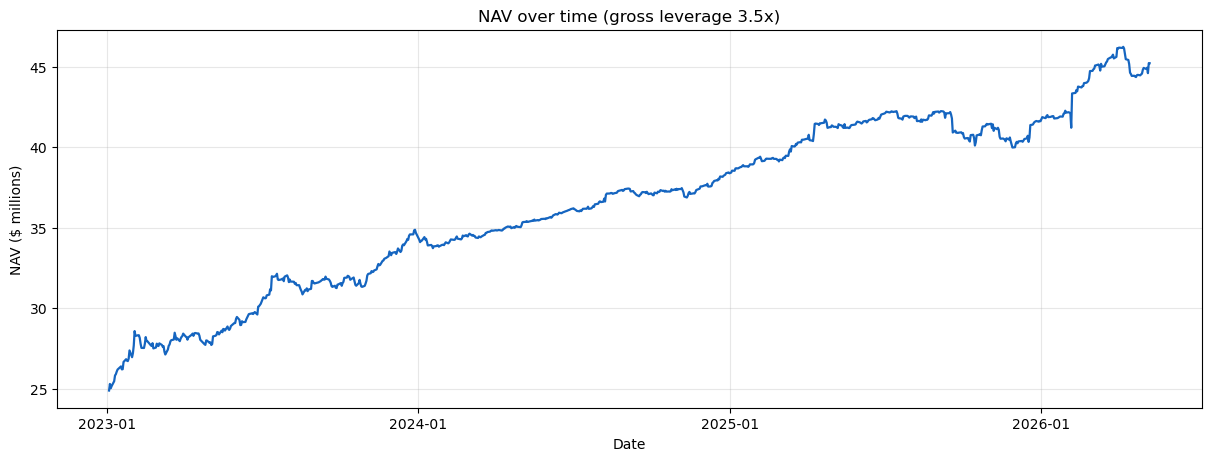

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_BT" not in dir() or not ALL_BT:
    raise RuntimeError("Run the backtest cell first (ALL_BT missing).")

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
nav = bt["nav"].astype(float)

fig, ax = plt.subplots(figsize=(12, 4.5), layout="constrained")
ax.plot(nav.index, nav / 1e6, color="#1565C0", lw=1.6)
ax.set_title(f"NAV over time (gross leverage {ref}x)")
ax.set_ylabel("NAV ($ millions)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(alpha=0.3)
plt.show()


## Pair allocation — % of total gross over time

Each pair’s gross exposure (long + short legs) as a percentage of total portfolio gross on each day, from `ALL_PAIR_GROSS` (same idea as v15).

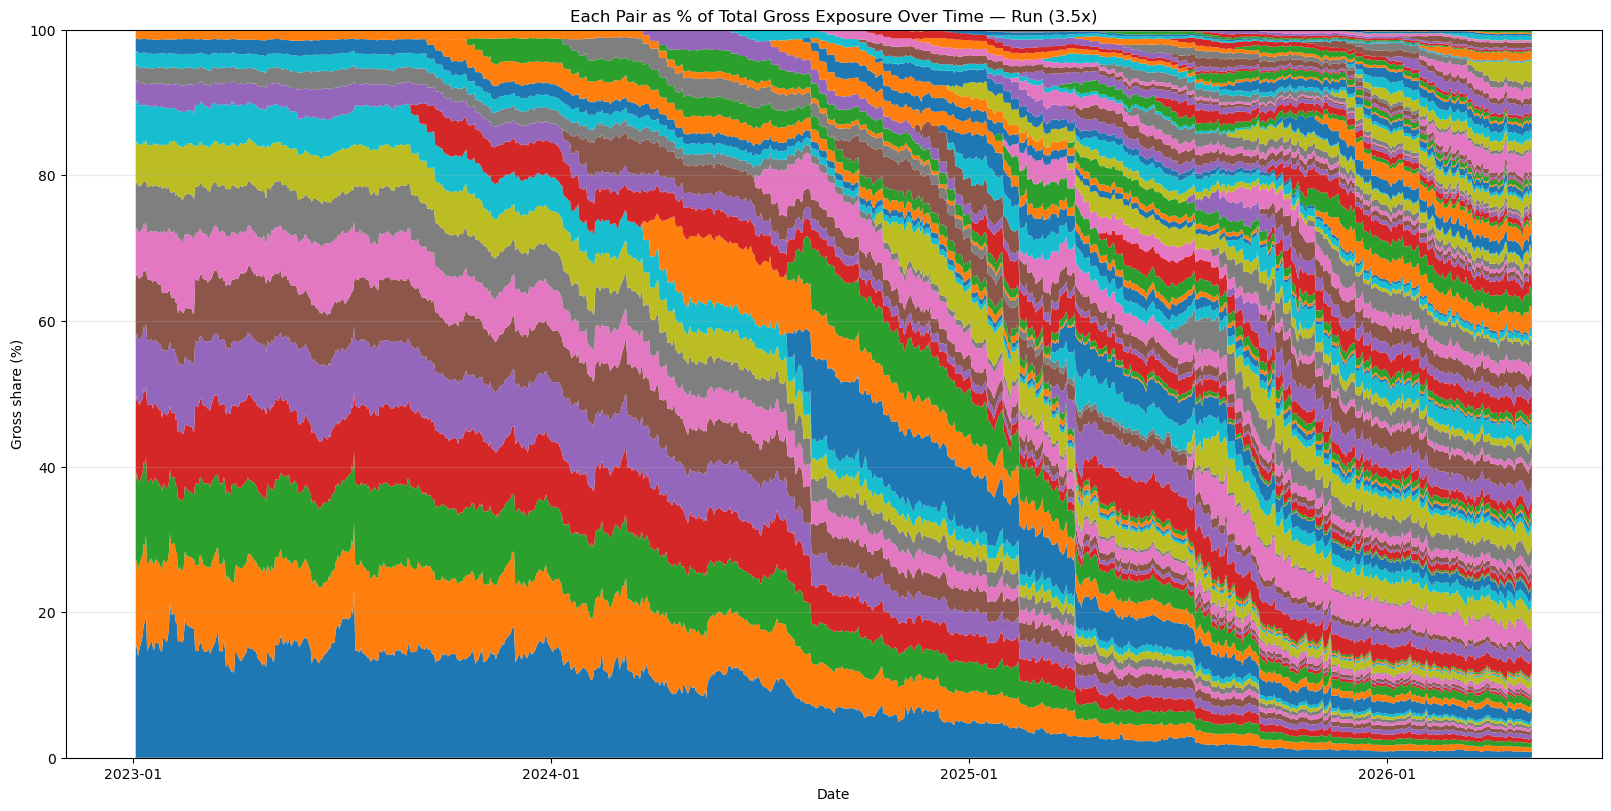

Pairs plotted: 116 | Date range: 2023-01-03 -> 2026-05-08
Top 15 pairs by average gross share (%):


,avg_gross_share_pct
COIN/CONL,8.050978
GDXJ/JNUG,6.137265
BABA/BABX,5.821936
GDX/GDXU,5.572940
SOXX/SOXL,4.789889
GDX/NUGT,4.415498
TSLA/TSLL,3.506252
FXI/YINN,3.295670
META/FBL,3.156886
KWEB/CWEB,2.830309


In [29]:
# ---- Pair gross share over time (% of total gross; each pair) ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run the backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")
print("Top 15 pairs by average gross share (%):")
display(pair_gross_pct.mean().sort_values(ascending=False).head(15).to_frame("avg_gross_share_pct"))

## Concentration — gross exposure by underlying

Bar chart of the aggregate portfolio *gross* weight contributed by each underlying (sum of pair weights sharing the same underlying).

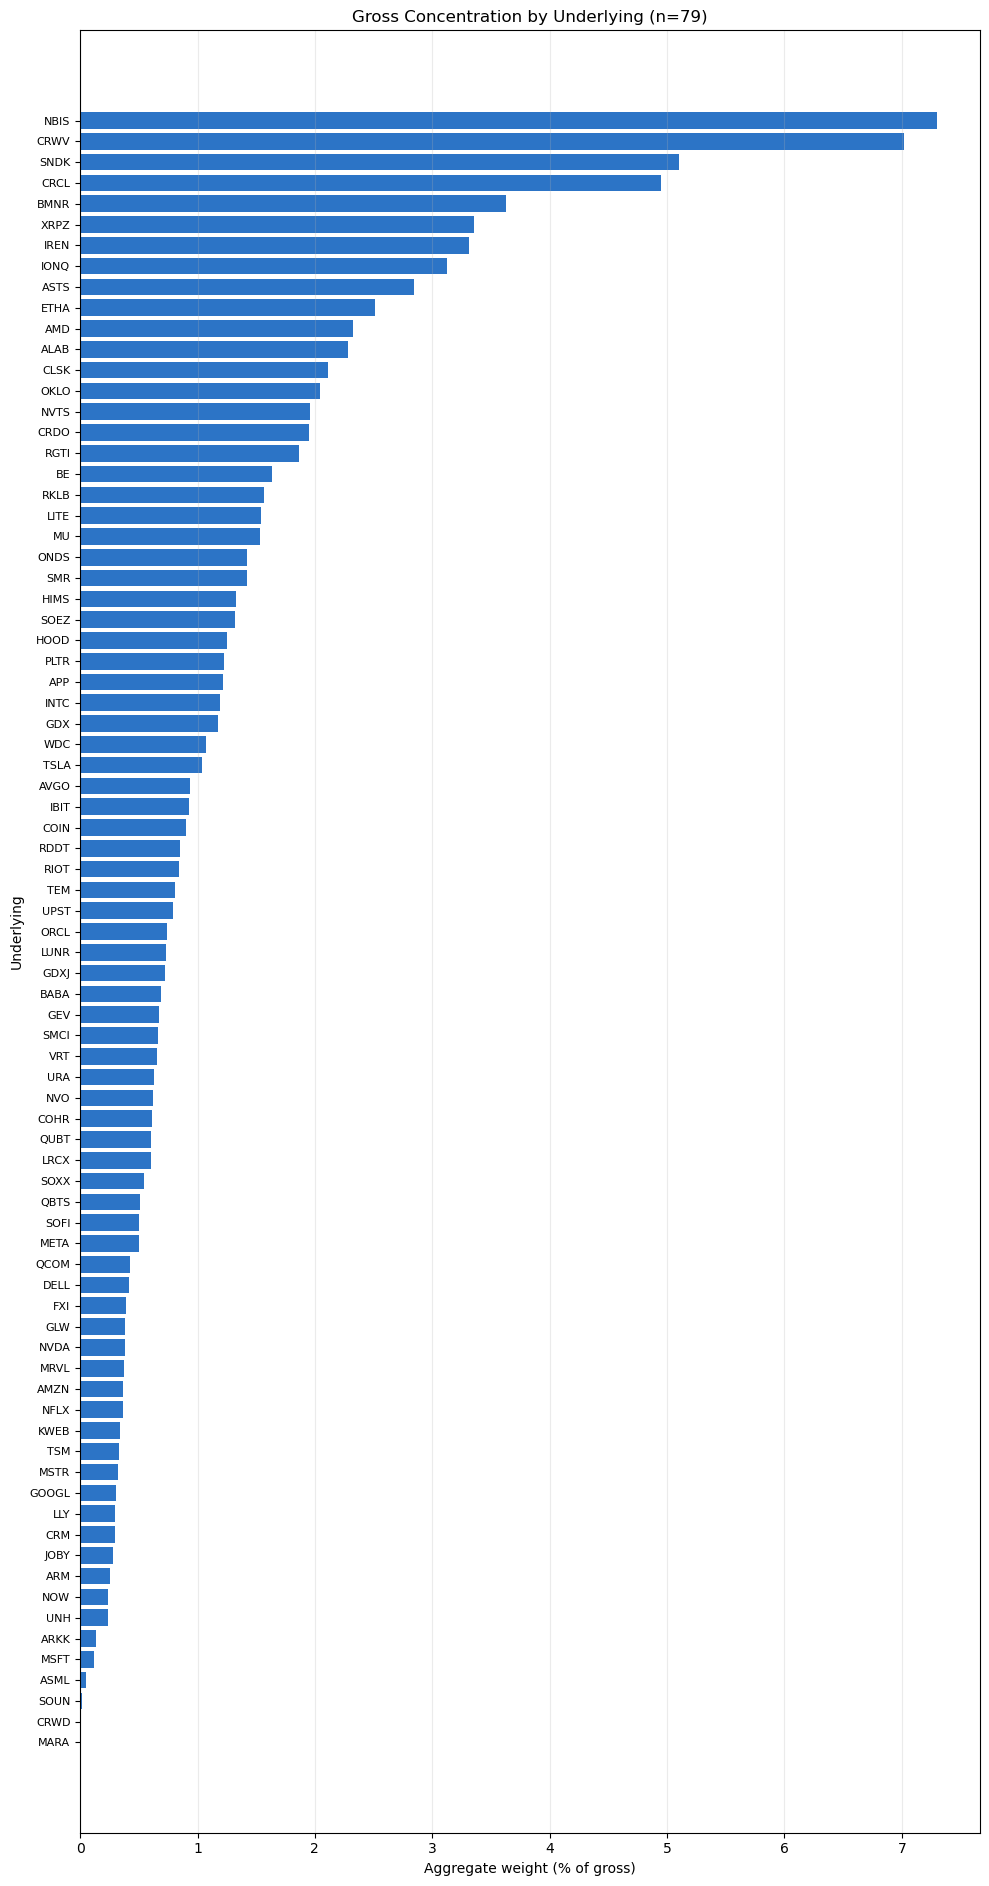

In [30]:
import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the sizing cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"].sum()
    .sort_values("weight", ascending=True)
)
if und_w.empty:
    raise RuntimeError("No strictly positive weights found.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))
ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Gross Concentration by Underlying (n={n})")
ax.set_xlabel("Aggregate weight (% of gross)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


In [31]:
ref = max(LEVERAGE_RUNS)

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    if "CANDIDATES" in globals() and "INCEPTION" in globals():
        UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
        UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
        print(f"[UNIVERSE] Rebuilt from CANDIDATES+INCEPTION: {len(UNIVERSE)} pairs")
    else:
        raise RuntimeError("Run universe setup cells first: CANDIDATES + INCEPTION/UNIVERSE are missing.")

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+5.17%  NAV pnl=$+2,128,707
2023-02-02  NAV ret=+3.21%  NAV pnl=$+890,082
2023-07-13  NAV ret=+2.83%  NAV pnl=$+880,245
2026-02-05  NAV ret=-2.15%  NAV pnl=$-904,766
2025-09-19  NAV ret=-2.09%  NAV pnl=$-874,369
2023-01-27  NAV ret=+1.90%  NAV pnl=$+510,273
2025-12-19  NAV ret=+1.90%  NAV pnl=$+770,060
2023-02-01  NAV ret=+1.76%  NAV pnl=$+479,306

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+5.17%  NAV pnl=$+2,128,707
         IONQ/QPUX  contrib=$-25,502
         NVTS/NVTX  contrib=$-11,613
           SMR/SMU  contrib=$+9,656
          IREN/IRE  contrib=$+9,257
         CRCL/CCUP  contrib=$+8,222

2023-02-02  NAV ret=+3.21%  NAV pnl=$+890,082
         COIN/CONL  contrib=$+682,912
          META/FBL  contrib=$+213,279
         TSLA/TSLL  contrib=$+50,695
         AMZN/AMZU 